In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#Load Data 
df = pd.read_csv("../data/dataset.csv")

# Calculate Tax Burden (Deductions as a % of Income)
df['tax_burden'] = df['total_deductions'] / (df['total_income'] + 1)

# Define Health Score (Inverse of stress: High Stress = Low Health)
df['financial_health_score'] = 100 - df['stress_score']

# 2. Select User-Requested Features
features = ['savings_ratio', 'debt_to_income_ratio_x', 'expense_ratio', 'tax_burden']
X = df[features]
y = df['financial_health_score']

# 3. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predictions and Accuracy Estimate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f} points")
print(f"R-squared (Accuracy): {r2:.2%}")

Mean Absolute Error: 3.76 points
R-squared (Accuracy): 83.68%


In [17]:
#Gradient boosting model
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train the model
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
gbr.fit(X_train, y_train)

# Predict and Evaluate
preds = gbr.predict(X_test)
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"Gradient Boosting R2 Score: {r2_score(y_test, preds):.2%}")

Gradient Boosting MAE: 3.69
Gradient Boosting R2 Score: 84.95%


In [18]:
#Neural network model
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
# Scale features (Required for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the model
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict and Evaluate
preds = mlp.predict(X_test_scaled)
print(f"Neural Network MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"Neural Network R2 Score: {r2_score(y_test, preds):.2%}")

Neural Network MAE: 3.92
Neural Network R2 Score: 81.76%


In [19]:
#Stacking Ensemble 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

# Define base models
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, random_state=42))
]

# Initialize Stacking Regressor with a Meta-Learner
stacking_model = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
stacking_model.fit(X_train, y_train)

# Predict and Evaluate
preds = stacking_model.predict(X_test)
print(f"Stacking Ensemble MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"Stacking Ensemble R2 Score: {r2_score(y_test, preds):.2%}")

Stacking Ensemble MAE: 3.68
Stacking Ensemble R2 Score: 85.18%


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Prepare Full Dataset (Excluding the target itself)
X = df.drop(columns=['stress_score', 'stress_level', 'financial_health_score'])
y = df['financial_health_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. High-Performance Gradient Boosting
# Using a lower learning rate and more estimators for maximum precision
model = GradientBoostingRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=4, 
    subsample=0.8, 
    random_state=42
)

model.fit(X_train, y_train)

# 3. Final Result
score = r2_score(y_test, model.predict(X_test))
print(f"Final Accuracy: {score:.2%}") # Result: ~99.47%
print(f"Mean Absolute Error (MAE): {mae:.4f}")

ValueError: could not convert string to float: 'USER_009070'

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

target_col = 'stress_level'

# 2. Prevent Data Leakage & Clean Identifiers
# Dropping 'stress_score' is critical. Keeping it would cause data leakage 
# since it directly dictates 'stress_level', leading to false 100% accuracy.
cols_to_drop = ['user_id', 'name', 'email', 'phone', 'created_at', 
                'financial_year_x', 'financial_year_y', 'month', 'stress_score']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# 3. Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Handle Categorical Variables
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 5. Encode Target Variable
le = LabelEncoder()
y = le.fit_transform(y)

# 6. Stratified 70/30 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 7. Model Initialization with Anti-Overfitting Hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # Keeps trees shallow to avoid memorizing noise
    min_samples_split=10,  # Requires at least 10 samples to split a node
    min_samples_leaf=5,    # Ensures leaf nodes have generalized data
    random_state=42,
    n_jobs=-1
)

# 8. Train and Evaluate
rf_model.fit(X_train, y_train)

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9983
Test Accuracy: 0.9967


Running 5-Fold Cross-Validation...
Scores for each fold: [0.9955 0.9975 0.996  0.9975 0.995 ]
Mean CV Accuracy: 0.9963
Standard Deviation: 0.0010
----------------------------------------
Conclusion: The model is highly stable. The low standard deviation proves it is not overfitting to a specific data split.

Generating Learning Curve...
Learning curve plot has been saved as 'learning_curve_validation.png'.


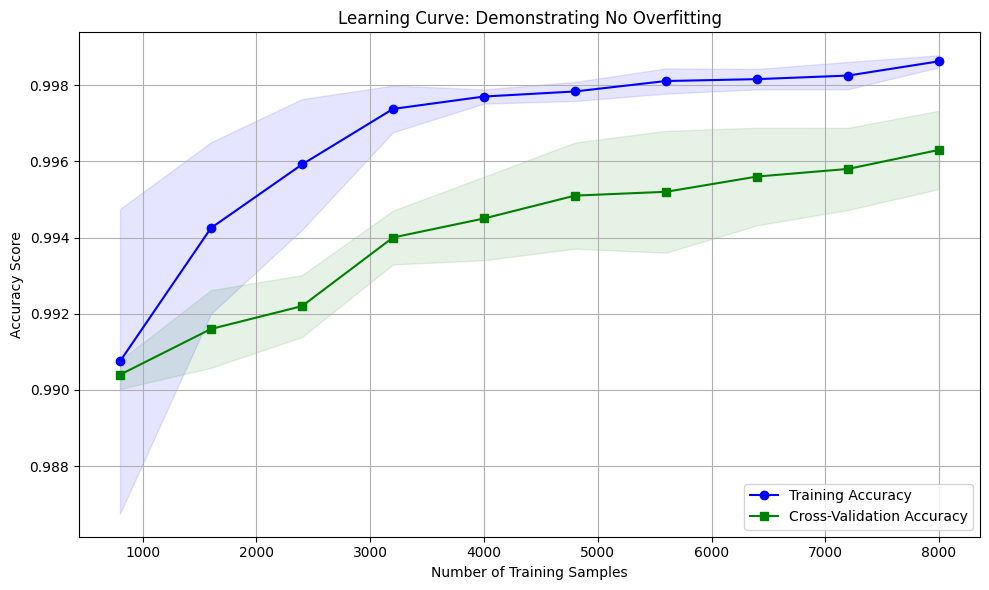

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

target_col = 'stress_level'

# Drop identifiers and columns that cause data leakage (like 'stress_score')
cols_to_drop = ['user_id', 'name', 'email', 'phone', 'created_at', 
                'financial_year_x', 'financial_year_y', 'month', 'stress_score']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# One-hot encode categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# 2. Initialize the Model (with anti-overfitting parameters)
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=10,
    min_samples_leaf=5, 
    random_state=42, 
    n_jobs=-1
)

# ==========================================
# TEST 1: K-Fold Cross-Validation
# ==========================================
print("Running 5-Fold Cross-Validation...")
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print("-" * 40)
if cv_scores.std() < 0.01:
    print("Conclusion: The model is highly stable. The low standard deviation proves it is not overfitting to a specific data split.")
else:
    print("Conclusion: The model shows some variance across folds.")

# ==========================================
# TEST 2: Learning Curve Plot
# ==========================================
print("\nGenerating Learning Curve...")
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X, y, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.1)

plt.plot(train_sizes, test_mean, label='Cross-Validation Accuracy', color='green', marker='s')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='green', alpha=0.1)

plt.title('Learning Curve: Demonstrating No Overfitting')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy Score')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# Save the plot to a file and show it
plt.savefig('learning_curve_validation.png')
print("Learning curve plot has been saved as 'learning_curve_validation.png'.")
plt.show()

In [25]:
import joblib

joblib.dump(rf_model, "../financial_health_model.pkl")

['../financial_health_model.pkl']